In [2]:
!pip install yfinance pandas numpy

import yfinance as yf
import pandas as pd
import numpy as np

In [3]:
tickers = ["EOAN.DE", "IBE.MC", "TTE.PA", "BP.L", "ENGI.PA", "EQNR.OL"]

data = yf.download(tickers, start="2020-01-01", end="2024-12-31")
prices = data["Close"]
print(prices.head())

#Quick check of NA
print(prices.isna().sum())

#We carry the last price to avoid NA bc of stock market closure
prices_clean = prices.ffill().dropna()
print(prices_clean.isna().sum())

#Log returns
log_returns = np.log(prices_clean / prices_clean.shift(1)).dropna()
print(log_returns.head())

#Risk profile
print(log_returns.describe())

#Annual data
annual_return = log_returns.mean() * 252
annual_volatility = log_returns.std() * np.sqrt(252)

print("Annual Return:")
print(annual_return)
print("\nAnnual volatility:")
print(annual_volatility)

[*********************100%***********************]  6 of 6 completed

Ticker            BP.L   ENGI.PA   EOAN.DE     EQNR.OL    IBE.MC     TTE.PA
Date                                                                       
2020-01-02  479.180115  9.530099  7.154590  123.809540  7.043618  33.182529
2020-01-03  492.334259  9.526855  7.088218  125.896835  7.011534  33.558891
2020-01-06  502.349518  9.536583  7.060627  128.714661  6.976393  34.044857
2020-01-07  497.067871  9.656561  7.009916  127.323143  6.840410  33.822128
2020-01-08  492.583527  9.643591  7.033034  127.740593  6.863328  33.909870
Ticker
BP.L       23
ENGI.PA     2
EOAN.DE     9
EQNR.OL    26
IBE.MC      4
TTE.PA      2
dtype: int64
Ticker
BP.L       0
ENGI.PA    0
EOAN.DE    0
EQNR.OL    0
IBE.MC     0
TTE.PA     0
dtype: int64
Ticker          BP.L   ENGI.PA   EOAN.DE   EQNR.OL    IBE.MC    TTE.PA
Date                                                                  
2020-01-03  0.027081 -0.000340 -0.009320  0.016718 -0.004565  0.011278
2020-01-06  0.020138  0.001021 -0.003900  0.022135 -0

In [4]:
#VaR 
#(what's the worst I can lose in a bad day?) If 95%, 95% of days wont surpass this threshold, but 5% will
VaR_95 = log_returns.quantile(0.05)
print(VaR_95)

#Sharpe ratio (Sharpe = Return / volatility)
#To management a portfolio, we have to see how much return do we get per unit of risk. Higher = better
sharpe = annual_return / annual_volatility
print(sharpe)

log_returns.to_csv("log_returns.csv")

#Correlation
correlation = log_returns.corr()
cov_matrix = log_returns.cov() * 252
print(cov_matrix)


Ticker
BP.L      -0.032851
ENGI.PA   -0.021880
EOAN.DE   -0.023139
EQNR.OL   -0.032755
IBE.MC    -0.020455
TTE.PA    -0.029210
Name: 0.05, dtype: float64
Ticker
BP.L      -0.116179
ENGI.PA    0.249287
EOAN.DE    0.330557
EQNR.OL    0.385193
IBE.MC     0.498785
TTE.PA     0.228522
dtype: float64
Ticker       BP.L   ENGI.PA   EOAN.DE   EQNR.OL    IBE.MC    TTE.PA
Ticker                                                             
BP.L     0.132260  0.038910  0.019028  0.079416  0.022091  0.099242
ENGI.PA  0.038910  0.070703  0.034953  0.021627  0.034117  0.037898
EOAN.DE  0.019028  0.034953  0.052479  0.012070  0.028907  0.021509
EQNR.OL  0.079416  0.021627  0.012070  0.114279  0.014120  0.069249
IBE.MC   0.022091  0.034117  0.028907  0.014120  0.050893  0.022885
TTE.PA   0.099242  0.037898  0.021509  0.069249  0.022885  0.103547


In [10]:
#MONTE-CARLO PORTFOLIO SIMULATION 1 - Data
#Number of random portfolios + weights
n_portfolios = 5000
n_assets = len(tickers)

#Generate random weights that sum  to 1
weights = np.random.random((n_portfolios, n_assets))
weights = weights / weights.sum(axis=1)[:, None]

weights = np.clip(weights, 0.05, 0.40)
weights = weights / weights.sum(axis=1)[:, None]
    #We clip the values outside 0f >0.05 and <0-40 to make realistic weights

#Expected annual return + covariance
mu = annual_return.values
cov = cov_matrix.values

#Portfolio returns + volatility
#Portfolio return = weighted average of individual returns
#Portfolio volatility = sqrt(w^T * Cov * w)
#einsum is a fast way to compute this for all 5'000 portfolios at once
port_return = weights.dot(mu)
port_vol = np.sqrt(np.einsum('ij,jk,ik->i', weights, cov, weights))
 

#Sharpe ratio (risk-free=0)
port_sharpe = port_return / port_vol

#Results
results = pd.DataFrame({
    "Return": port_return,
    "Volatility": port_vol,
    "Sharpe": port_sharpe
        })

#Add weights to the Data Frame
weights_df = pd.DataFrame(weights, columns=tickers)
full_results = pd.concat([results, weights_df], axis=1)

full_results.head()

,Return,Volatility,Sharpe,EOAN.DE,IBE.MC,TTE.PA,BP.L,ENGI.PA,EQNR.OL
0,0.064409,0.209647,0.307225,0.171860,0.188190,0.163917,0.048574,0.231477,0.195982
1,0.059946,0.220119,0.272335,0.236997,0.223123,0.061943,0.114012,0.227547,0.136379
2,0.061071,0.213177,0.286480,0.209433,0.142672,0.161217,0.055851,0.238557,0.192270
3,0.082147,0.199281,0.412218,0.047998,0.195451,0.215778,0.122127,0.210112,0.208533
4,0.061522,0.231493,0.265763,0.192472,0.214418,0.144015,0.169165,0.049337,0.230593


Max Sharpe Portfolio:
Return        0.099672
Volatility    0.198062
Sharpe        0.503238
EOAN.DE       0.048921
IBE.MC        0.048921
TTE.PA        0.138778
BP.L          0.292763
ENGI.PA       0.391368
EQNR.OL       0.079249
Name: 2546, dtype: float64


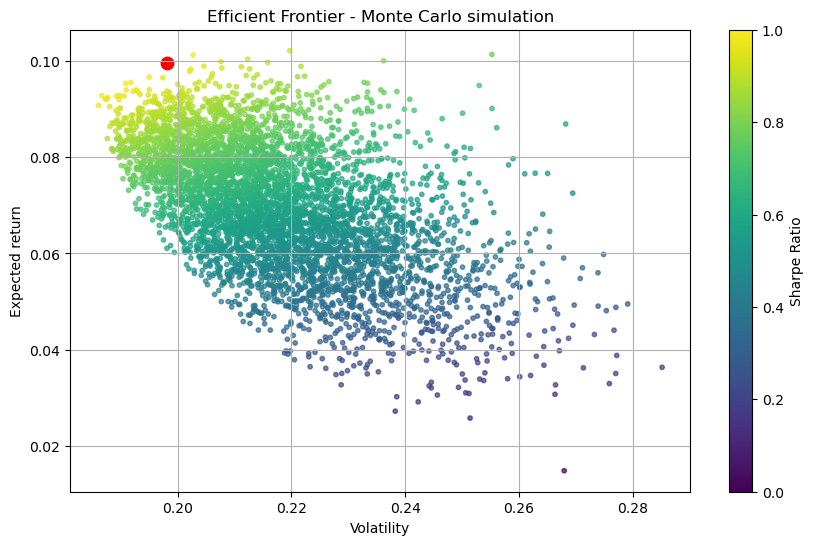

In [11]:
#MONTE-CARLO PORTFOLIO SIMULATION 2 - Efficient frontier

#Find the portfolio composition with the highest Sharpe ratio
max_sharpe_idx = full_results["Sharpe"].idxmax()

#Extract the full row (return, vol, sharpe, weights)
max_sharpe_port = full_results.loc[max_sharpe_idx]

print("Max Sharpe Portfolio:")
print(max_sharpe_port)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

#Scatter plot of all random portfolios
plt.scatter(
    full_results["Volatility"],
    full_results["Return"],
    c=full_results["Sharpe"],
    cmap="viridis",
    s=10,
    alpha=0.7
)

plt.scatter(
    max_sharpe_port["Volatility"],
    max_sharpe_port["Return"],
    color="red",
    s=80,
    label="Max Sharpe")
        
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected return")
plt.title("Efficient Frontier - Monte Carlo simulation")
plt.grid(True)
plt.show()

#The upper left grid is the efficient frontier, where the risk is lowest and reward is highest

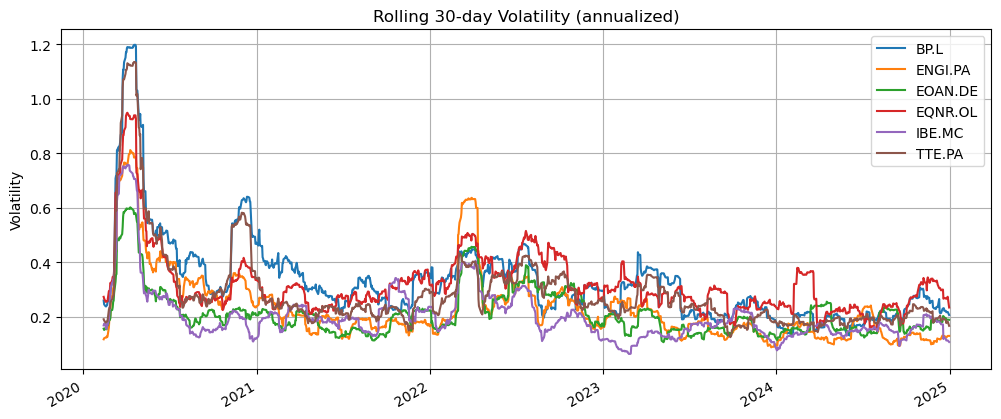

In [15]:
#ROLLING VOLATILITY (30-day window)
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)

rolling_vol.plot(figsize=(12, 5), title = "Rolling 30-day Volatility (annualized)")
plt.xlabel("")
plt.ylabel("Volatility")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()